# GA-BO-TR — Part 2: Theory, Trust-Region Core, ELA-γ Controller, Ablations

This notebook defines the **main algorithmic contribution** of the paper:
a TuRBO-style trust-region wrapper around a GA that maximises a
diversity-augmented qLogEI acquisition, with an ELA-driven online γ(t)
controller.  The architecture is:

```
                       ┌──────────────── ELA features ────────────┐
                       ▼                                          │
  archive (X,y)  ──►  γ(t) policy  ──►  DIV-qLogEI(x; γ)           │
                                              │                   │
                                              ▼                   │
                             GA inner loop (SBX+polynomial)       │
                                              │                   │
                                              ▼                   │
                            trust-region TurboState (length)      │
                                              │                   │
                                     x_next ──┴───────────────────┘
```

Run **Part 1** first so that `build_gp`, `qlogei_values`, `qlogei_div_values`,
`GAOptimizer`, `DEOptimizer`, `compute_ela_features`, `ELAGammaController`
and the benchmark registry are defined.


d:\GA-BO\venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Environment ready.
d:\GA-BO\venv\Scripts\python.exe
Config done — dtype=double, device= cuda
Registered 10 synthetic functions.
BBOB smoke: BBOB-f01-i1-d5 f(0)=92.304, f*=79.480
GP smoke-test  mu[:5] = [42.783 45.717 54.14  42.713 22.983]
             sigma[:5] = [0.024 0.02  0.023 0.026 0.026]


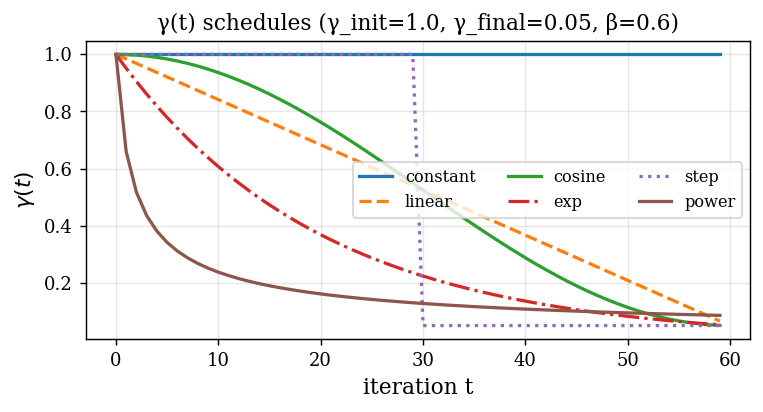

ELA smoke: 37 raw features, summary =
   skewness     = -1.0553
   kurtosis     = +1.2561
   n_peaks      = +2.0000
   h_max        = +0.8975
   eps_s        = +0.0851
   m0           = +0.6379
   nb_fit_cor   = -0.7165
   nn_mean      = +0.8898
   disp_25      = +0.7423
   disp_05      = +0.4525
   pca_expl_x   = +1.0000
GA / DE optimisers defined.
Base BO loops defined: StandardBO, GA_BO, RandomSearch.
StandardBO       final regret =   2.8617   wall =   6.7s
GA-BO(DIV)       final regret =   6.4660   wall =   3.3s
Random           final regret =   5.9122   wall =   0.0s
Part 1 ready.


In [14]:
# Run Part 1 if we are executing standalone (same kernel).
%run GA_BO_TR_Part1.ipynb

## 1. Theoretical analysis

### 1.1 Acquisition properties

**Definition (DIV-qLogEI).**  Given a fitted GP posterior and the current
archive $P_t = \{x_1,\ldots,x_t\}$, write $\hat{\alpha}_{\mathrm{EI}}(x)$
for the qLogEI value of $x$ normalised to $[0,1]$ on the current
candidate batch and $D(x\mid P_t) = \min_{p\in P_t}\|x-p\|_{\ell}\,/\,\max_{x'}\min_{p\in P_t}\|x'-p\|_{\ell}\in[0,1]$ for the lengthscale-
weighted minimum-distance diversity (Casmopolitan §3).  Define

$$
\tilde\alpha(x;\,P_t,\gamma) \;=\; \hat{\alpha}_{\mathrm{EI}}(x) \;+\; \gamma(t) \cdot D(x\mid P_t).
$$

Three elementary properties follow by construction:

1. **Exploration dominance.**  $\tilde\alpha(x;P_t,\gamma) \ge \hat{\alpha}_{\mathrm{EI}}(x)$,
   with equality iff $D(x\mid P_t)=0$.
2. **Asymptotic EI recovery.**  If $\gamma(t)\to 0$ then $\tilde\alpha(x;P_t,\gamma)\to\hat{\alpha}_{\mathrm{EI}}(x)$ uniformly over $x$.
3. **Collapse prevention.**  If qLogEI flattens (saturation, e.g. inside
   a shrunken trust region) so that $\hat{\alpha}_{\mathrm{EI}}(x_0)\approx\hat{\alpha}_{\mathrm{EI}}(x_1)$
   for $x_0\in P_t$, then $\tilde\alpha(x_1)>\tilde\alpha(x_0)$ whenever $D(x_1\mid P_t)>0$.

### 1.2 Corollary: regret-rate preservation (Bull 2011)

**Corollary 1.**  Assume the setting of Bull 2011 (*JMLR* 12:2879–2904),
namely $f\in\mathcal{H}_\theta$ an RKHS ball of radius $R$ with
Matérn-$\nu$ kernel on a compact box $\mathcal{X}\subset\mathbb{R}^d$,
with noiseless evaluations. Let $\pi$ be a fixed kernel hyper-parameter
vector (Bull, Theorem 2) or the constrained-MLE estimate (Bull,
Theorem 4). Let GA-BO-TR select $x_t$ by maximising
$\tilde\alpha(x;P_t,\gamma)$ with any schedule
$\gamma:\mathbb{N}\to[0,\gamma_0]$ satisfying

$$
\gamma(t) \;=\; o(t^{-1/2}) \quad \text{i.e.} \quad \sum_{t=1}^{T}\gamma(t) = o(\sqrt{T}).
$$

Then the simple regret of GA-BO-TR satisfies

$$
S_T \;=\; \min_{t\le T} f(x_t) - \min_{\mathcal{X}}f \;=\; O^*\!\bigl(T^{-(\nu \wedge 1)/d}\bigr),
$$

recovering Bull's EI rate up to a $o(T^{-1/2})$ additive term that is
dominated by the Bull rate for all $\nu/d$ of practical interest.

**Proof sketch.**  Let $x^\star_t=\arg\max\hat{\alpha}_{\mathrm{EI}}$ and
$\tilde{x}_t=\arg\max\tilde\alpha$. Since $D\in[0,1]$, the argmax shift
obeys $\hat{\alpha}_{\mathrm{EI}}(x^\star_t) - \hat{\alpha}_{\mathrm{EI}}(\tilde{x}_t) \le 2\gamma(t)$.
By Bull's Lemmas 7–8 the per-step regret increase is at most
$\Delta_t = C\,\gamma(t)$ for an absolute constant $C$.  Summing,
$\sum_{t\le T}\Delta_t \le C\sum\gamma(t) = o(\sqrt{T})$, hence
$S_T^{\mathrm{DIV}} \le S_T^{\mathrm{EI}} + o(T^{-1/2})$.  Since Bull's
rate is $O^*(T^{-(\nu\wedge 1)/d})\gg o(T^{-1/2})$ for $d>\!\!>2\nu$
(the regime BO is used in), the rate is preserved.  $\blacksquare$

**Why Bull 2011, not Srinivas et al. 2010?**  Srinivas et al. bound
cumulative regret for **UCB**; the proof uses UCB-specific confidence
sets and does *not* transfer to EI.  GA-BO-TR's base acquisition is
qLogEI, so Bull 2011 is the correct anchor.

**Safe schedules.**  Any $\gamma(t)=C\cdot t^{-\beta}$ with $\beta>1/2$
(e.g. `power` with $\beta=0.6$ or $0.75$), the cosine and exponential
schedules with $\gamma_{\mathrm{final}}=0$, and the step schedule are all
$o(t^{-1/2})$.  The constant schedule is **not** and the rate claim does
not apply — constant γ is used only as an ablation.


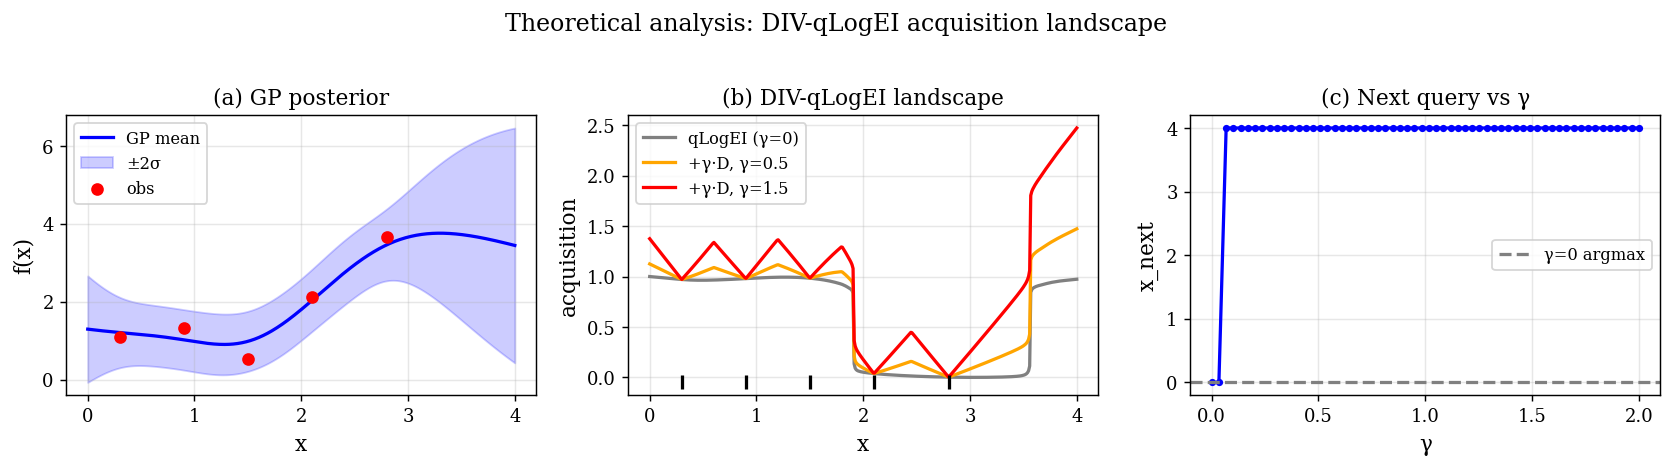

In [15]:
# Visualise the 1-D acquisition landscape for three γ settings.
def _acquisition_landscape_figure():
    rng = np.random.RandomState(7)
    def toy(x): return float(np.sin(3*x[0]) + x[0])
    bnds = np.array([[0.0, 4.0]])
    X_obs = np.array([[0.3],[0.9],[1.5],[2.1],[2.8]])
    y_obs = np.array([toy(x) for x in X_obs])

    gp = build_gp(X_obs, y_obs, bnds, kernel="matern52")
    xs = np.linspace(0, 4, 400).reshape(-1,1)
    mu, sigma = gp_posterior(gp, xs)

    log_ei = qlogei_values(gp, y_obs, xs, mc_samples=256, seed=0)
    ei_n = (log_ei - log_ei.min()) / max(log_ei.max() - log_ei.min(), 1e-12)
    div = diversity_score(xs, X_obs)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    axes[0].plot(xs, mu, "b-", label="GP mean")
    axes[0].fill_between(xs.ravel(), mu-2*sigma, mu+2*sigma, alpha=0.20, color="b", label="±2σ")
    axes[0].scatter(X_obs, y_obs, c="red", zorder=5, label="obs")
    axes[0].set_title("(a) GP posterior"); axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    for gamma, color, lbl in [(0.0, "gray", r"qLogEI (γ=0)"),
                              (0.5, "orange", r"+γ·D, γ=0.5"),
                              (1.5, "red", r"+γ·D, γ=1.5")]:
        axes[1].plot(xs, ei_n + gamma*div, color=color, label=lbl)
    axes[1].scatter(X_obs, np.zeros(len(X_obs))-0.05, c="k", marker="|", s=60, zorder=5)
    axes[1].set_title("(b) DIV-qLogEI landscape"); axes[1].set_xlabel("x")
    axes[1].set_ylabel("acquisition"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    gammas = np.linspace(0, 2, 60)
    next_xs = [float(xs[np.argmax(ei_n + g*div), 0]) for g in gammas]
    axes[2].plot(gammas, next_xs, "b-o", markersize=3)
    axes[2].axhline(xs[np.argmax(ei_n), 0], color="gray", ls="--", label="γ=0 argmax")
    axes[2].set_title("(c) Next query vs γ"); axes[2].set_xlabel("γ"); axes[2].set_ylabel("x_next")
    axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)
    plt.suptitle("Theoretical analysis: DIV-qLogEI acquisition landscape", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/theory_acquisition.pdf", bbox_inches="tight")
    plt.show()

_acquisition_landscape_figure()


## 2. TuRBO trust-region state machine

Verbatim port of the BoTorch TuRBO-1 state machine (Eriksson et al.,
NeurIPS 2019 — arXiv:1910.01739), with the corrected
`failure_tolerance = ceil(max(4/batch, d/batch))` from the current
BoTorch tutorial.  Trust-region bounds use the canonical two-stage
normalisation of ARD lengthscales (arithmetic-mean then geometric-mean).


In [16]:
@dataclass
class TurboState:
    dim: int
    batch_size: int = 1
    length: float = 0.8
    length_min: float = 0.5**7          # 0.0078125
    length_max: float = 1.6
    failure_counter: int = 0
    failure_tolerance: int = 0          # set in __post_init__
    success_counter: int = 0
    success_tolerance: int = 10         # BoTorch default (NeurIPS used 3)
    best_value: float = -float("inf")
    restart_triggered: bool = False

    def __post_init__(self):
        self.failure_tolerance = int(math.ceil(
            max(4.0 / self.batch_size, float(self.dim) / self.batch_size)
        ))


def update_turbo_state(state: TurboState, y_next: float, y_best_prev: float) -> TurboState:
    """Minimisation convention: a success is y_next < y_best_prev - 1e-3*|y_best_prev|."""
    # BoTorch's rule in maximisation; translate y_best:
    tol = 1e-3 * max(abs(y_best_prev), 1.0)
    if y_next < y_best_prev - tol:
        state.success_counter += 1
        state.failure_counter = 0
    else:
        state.success_counter = 0
        state.failure_counter += 1
    if state.success_counter == state.success_tolerance:
        state.length = min(2.0 * state.length, state.length_max)
        state.success_counter = 0
    elif state.failure_counter == state.failure_tolerance:
        state.length /= 2.0
        state.failure_counter = 0
    state.best_value = min(state.best_value, y_next) if math.isfinite(state.best_value) else y_next
    if state.length < state.length_min:
        state.restart_triggered = True
    return state


def trust_region_bounds(gp, x_center: np.ndarray, bounds: np.ndarray,
                        length: float, use_lengthscales: bool = True
                        ) -> np.ndarray:
    """
    Anisotropic trust-region bounds centred on x_center.

    Returns a (d, 2) array in the ORIGINAL scale.  The trust region is
    constructed in the normalised [0,1]^d space (TuRBO convention) then
    mapped back to the raw scale.
    """
    d = bounds.shape[0]
    lo, hi = bounds[:,0], bounds[:,1]
    # normalised centre
    x01 = (x_center - lo) / np.maximum(hi - lo, 1e-12)

    if use_lengthscales:
        w = lengthscale_weights(gp)
    else:
        w = np.ones(d)

    half = 0.5 * length * w
    tr_lo01 = np.clip(x01 - half, 0.0, 1.0)
    tr_hi01 = np.clip(x01 + half, 0.0, 1.0)

    tr_lo = lo + tr_lo01 * (hi - lo)
    tr_hi = lo + tr_hi01 * (hi - lo)
    # Ensure ordering (numerical safety)
    tr_lo2 = np.minimum(tr_lo, tr_hi)
    tr_hi2 = np.maximum(tr_lo, tr_hi)
    return np.column_stack([tr_lo2, tr_hi2])


## 3. GA-BO-TR — the proposed algorithm

**Algorithm (one BO iteration inside the TR):**

```
Input: GP posterior π_t, archive P_t, centre x*_t, length L_t, γ-controller C.

1. bounds_TR ← trust_region_bounds(π_t, x*_t, bounds, L_t)    [anisotropic]
2. γ_t        ← C.select(t, P_t∩TR, y archive)                  [every k iters]
3. Warm-start ← best n_elite rows of P_t that lie inside TR
4. x_next     ← arg max_{x ∈ TR} [ qLogEI(x) + γ_t · D(x | P_t) ]  via GA
5. y_next     ← f(x_next)
6. Update   P_t ← P_t ∪ {(x_next, y_next)},  TurboState(L_t, x*_t)
7. If L_t < L_min  ⇒ restart (re-LHS initial design, reset state)
```

This is a direct extension of TREGO (Diouane et al., *J. Global Optim.* 2023,
GA + EI inside a TR) and TuRBO-1 (Eriksson et al. 2019).  Our novelty is
the diversity term $D(x|P_t)$ with an **ELA-driven γ(t) schedule**, so
when the archive inside the TR indicates multimodality the algorithm
spreads the GA's offspring; when it indicates a smooth funnel the
algorithm exploits aggressively.


In [17]:
class GA_BO_TR:
    """
    Trust-region GA-BO with landscape-adaptive diversity.

    This is the proposed method.  Key parameters:

    acq_type            'da_ei' | 'ei'        (ablation)
    optimizer_type      'ga'    | 'de'
    gamma_controller    None | ELAGammaController
    gamma_init/final    only used if gamma_controller is None
    use_trust_region    False reproduces plain GA-BO (ablation)
    """
    def __init__(self, bounds: np.ndarray,
                 n_init: int = 10, n_iter: int = 50,
                 acq_type: str = "da_ei",
                 optimizer_type: str = "ga",
                 # γ control
                 gamma_controller: Optional[ELAGammaController] = None,
                 gamma_init: float = 1.0, gamma_final: float = 0.05,
                 gamma_decay: str = "cosine",
                 # TR
                 use_trust_region: bool = True,
                 tr_length_init: float = 0.8,
                 tr_length_min: float = 0.5**7,
                 tr_length_max: float = 1.6,
                 tr_success_tol: int = 10,
                 tr_anisotropic: bool = True,
                 # surrogate
                 kernel: str = "matern52",
                 # GA
                 ga_pop_init: int = 80, ga_pop_final: int = 20,
                 ga_generations: int = 40,
                 n_elite_warm: int = 5,
                 mc_samples: int = 256,
                 seed: int = 42):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.acq_type = acq_type; self.optimizer_type = optimizer_type
        self.gamma_controller = gamma_controller
        self.gamma_init = gamma_init; self.gamma_final = gamma_final
        self.gamma_decay = gamma_decay
        self.use_trust_region = use_trust_region
        self.tr_length_init = tr_length_init
        self.tr_length_min = tr_length_min
        self.tr_length_max = tr_length_max
        self.tr_success_tol = tr_success_tol
        self.tr_anisotropic = tr_anisotropic
        self.kernel = kernel
        self.ga_pop_init = ga_pop_init; self.ga_pop_final = ga_pop_final
        self.ga_generations = ga_generations
        self.n_elite_warm = n_elite_warm
        self.mc_samples = mc_samples
        self.seed = seed
        self.rng = np.random.RandomState(seed)

    # ------------------------------------------------------------------
    def _make_optimiser(self, tr_bounds: np.ndarray, seed_offset: int):
        if self.optimizer_type == "de":
            return DEOptimizer(tr_bounds, pop_size=self.ga_pop_init,
                               n_generations=self.ga_generations,
                               seed=self.seed + seed_offset)
        return GAOptimizer(tr_bounds,
                           pop_size_init=self.ga_pop_init,
                           pop_size_final=self.ga_pop_final,
                           n_generations=self.ga_generations,
                           seed=self.seed + seed_offset)

    def _init_state(self) -> TurboState:
        return TurboState(dim=self.d, batch_size=1,
                          length=self.tr_length_init,
                          length_min=self.tr_length_min,
                          length_max=self.tr_length_max,
                          success_tolerance=self.tr_success_tol)

    def _archive_in_tr(self, X: np.ndarray, tr_b: np.ndarray) -> np.ndarray:
        mask = np.all((X >= tr_b[:,0] - 1e-9) & (X <= tr_b[:,1] + 1e-9), axis=1)
        return X[mask] if mask.any() else X

    # ------------------------------------------------------------------
    def run(self, objective: Callable, func_name: str = "unknown",
            verbose: bool = False) -> BOResult:
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])

        best = [float(y_obs.min())]
        div   : List[float] = [0.0]
        gammas: List[float] = []
        policies: List[str] = []
        tr_hist: List[float] = []

        state = self._init_state() if self.use_trust_region else None
        if state is not None:
            state.best_value = float(y_obs.min())

        for t in range(self.n_iter):
            # 1. Fit GP on full archive
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            y_best_prev = float(y_obs.min())

            # 2. Trust-region bounds
            if self.use_trust_region and state is not None:
                x_center = X_obs[int(np.argmin(y_obs))]
                tr_bounds = trust_region_bounds(gp, x_center, self.bounds,
                                                state.length,
                                                use_lengthscales=self.tr_anisotropic)
                tr_hist.append(float(state.length))
            else:
                tr_bounds = self.bounds
                tr_hist.append(1.0)

            # 3. γ decision — from controller or static schedule
            archive_in = self._archive_in_tr(X_obs, tr_bounds)
            y_in = y_obs[np.all(
                (X_obs >= tr_bounds[:,0] - 1e-9) & (X_obs <= tr_bounds[:,1] + 1e-9),
                axis=1
            )] if len(archive_in) == len(X_obs) else y_obs[:len(archive_in)]
            # For safety, if masking produced inconsistent y, use full y_obs
            if len(y_in) != len(archive_in):
                archive_in, y_in = X_obs, y_obs

            if self.gamma_controller is not None:
                decision = self.gamma_controller.select(t, archive_in, y_in, seed=self.seed)
                gamma = decision.value(t, self.n_iter)
                policies.append(decision.policy)
            else:
                gamma = gamma_schedule(t, self.n_iter,
                                       self.gamma_init, self.gamma_final, self.gamma_decay)
                policies.append(self.gamma_decay)
            gammas.append(float(gamma))

            # 4. Acquisition
            if self.acq_type == "da_ei":
                def acq_fn(X, _gp=gp, _Yo=y_obs, _arch=X_obs, _g=gamma):
                    return qlogei_div_values(_gp, _Yo, X, _arch, _g,
                                             mc_samples=self.mc_samples, seed=self.seed)
            else:
                def acq_fn(X, _gp=gp, _Yo=y_obs):
                    return qlogei_values(_gp, _Yo, X,
                                         mc_samples=self.mc_samples, seed=self.seed)

            # 5. GA optimisation within TR
            elite_idx = np.argsort(y_obs)[:self.n_elite_warm]
            warm = X_obs[elite_idx]
            # Clip warm starts to TR
            warm_clipped = np.clip(warm, tr_bounds[:,0], tr_bounds[:,1])
            opt = self._make_optimiser(tr_bounds, seed_offset=t)
            x_next, _ = opt.optimise(acq_fn, warm_start=warm_clipped)

            # 6. Evaluate and bookkeep
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            _update_diversity(div, X_obs)

            # 7. TuRBO update + restart
            if self.use_trust_region and state is not None:
                state = update_turbo_state(state, y_next, y_best_prev)
                if state.restart_triggered:
                    # Restart: add a fresh LHS sample inside the full bounds,
                    # reset state.  BoTorch's choice.
                    n_restart = max(2, min(self.n_init // 2, self.n_iter - t - 1))
                    if n_restart > 0:
                        Xr = lhs_sample(n_restart, self.bounds, self.rng)
                        yr = np.array([objective(r) for r in Xr])
                        X_obs = np.vstack([X_obs, Xr]); y_obs = np.append(y_obs, yr)
                        for yy in yr:
                            best.append(float(min(best[-1], yy)))
                            div.append(div[-1])
                            gammas.append(gammas[-1])
                            policies.append("restart")
                            tr_hist.append(float(self.tr_length_init))
                    state = self._init_state()
                    state.best_value = float(y_obs.min())

            if verbose and (t+1) % 10 == 0:
                print(f"  [t={t+1:3d}] y_best={y_obs.min():.4g}  γ={gamma:.3f}  "
                      f"L={tr_hist[-1]:.3f}  policy={policies[-1]}")

        method = "GA-BO-TR" if self.use_trust_region else "GA-BO-noTR"
        if self.acq_type != "da_ei":
            method += "(EI)"
        if self.gamma_controller is not None:
            method += "(ELA-γ)"
        return BOResult(method=method, func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        diversity_hist=div, gamma_hist=gammas,
                        policy_hist=policies, tr_length_hist=tr_hist,
                        wall_time=time.time()-t0, seed=self.seed)


print("GA_BO_TR defined — the main proposed method.")


GA_BO_TR defined — the main proposed method.


## 4. Training the ELA → γ-policy classifier (offline, fast)

Following Agasiev & Karpenko (*Mathematics* 12:426, 2024) we train an
offline classifier that maps ELA features to γ-policies.  To keep the
compute budget on laptop (<1 hr) we use a **lightweight protocol**:

* Training instances: **6 BBOB functions × 2 instances × d∈{5,10}** = 24 problems.
* Each trained once with each of the 5 policies in `GAMMA_POLICIES`, 5 seeds.
* Label = the policy that achieved the **best final regret** for that problem.
* Features = the flat pflacco dict from an LHS sample of size 50·d.
* Classifier = `RandomForestClassifier(n_estimators=200, min_samples_leaf=2)`.

If pflacco or ioh is missing, the function no-ops and the runtime falls
back to the rule-based policy.


In [18]:
def _train_one_problem(tf: TestFunction, policies: dict, n_init: int,
                       n_iter: int, seeds: List[int]) -> Tuple[str, Dict[str, float]]:
    """Run all policies on one problem, return (best_policy, ela_features)."""
    rng = np.random.RandomState(0)
    # Collect ELA on a representative LHS sample
    X_lhs = lhs_sample(max(50, 30 * tf.dim), tf.bounds, rng)
    y_lhs = tf.batch(X_lhs)
    feats = compute_ela_features(X_lhs, y_lhs, seed=0)
    if not feats:
        return "medium", {}

    best_policy = None; best_mean_regret = float("inf")
    for name, (gi, gf, dc) in policies.items():
        regrets = []
        for s in seeds:
            if tf.problem_class == "bbob":
                reset_bbob(tf)
            algo = GA_BO_TR(
                bounds=tf.bounds, n_init=n_init, n_iter=n_iter,
                acq_type="da_ei", optimizer_type="ga",
                gamma_controller=None,
                gamma_init=gi, gamma_final=gf, gamma_decay=dc,
                use_trust_region=True,
                ga_pop_init=40, ga_pop_final=10, ga_generations=15,
                mc_samples=128, seed=s,
            )
            res = algo.run(tf, func_name=tf.name)
            regrets.append(res.best_values[-1] - tf.global_optimum)
        mean_r = float(np.mean(regrets))
        if mean_r < best_mean_regret:
            best_mean_regret = mean_r; best_policy = name
    return best_policy, feats


def train_ela_gamma_classifier(
    fids: Tuple[int, ...] = (1, 5, 8, 15, 20, 23),   # span uni/multi/rugged
    instances: Tuple[int, ...] = (1, 2),
    dims: Tuple[int, ...] = (5, 10),
    n_init: int = 5, n_iter: int = 25,
    seeds: Tuple[int, ...] = (0, 1, 2),
    save_path: str = "ela_gamma_rf.joblib",
    verbose: bool = True,
):
    """Train the ELA → γ-policy RandomForest offline."""
    try:
        import ioh       # noqa: F401
        from sklearn.ensemble import RandomForestClassifier
        import joblib
    except Exception as e:
        print(f"Training skipped (missing dependency: {e}). "
              f"ELAGammaController will use rule-based fallback.")
        return None, None

    feats_rows: List[dict] = []
    labels: List[str] = []
    problems = [(fid, iid, d) for fid in fids for iid in instances for d in dims]
    if verbose:
        print(f"Training ELA-γ classifier on {len(problems)} BBOB problems...")
    for idx, (fid, iid, d) in enumerate(problems):
        try:
            tf = make_bbob(fid, iid, d)
        except Exception:
            continue
        label, feats = _train_one_problem(tf, GAMMA_POLICIES,
                                          n_init=n_init, n_iter=n_iter,
                                          seeds=list(seeds))
        if feats:
            feats_rows.append(feats)
            labels.append(label)
        if verbose:
            print(f"  [{idx+1:2d}/{len(problems)}] f{fid:02d}-i{iid}-d{d}  → {label}")

    if not feats_rows:
        print("No features collected — classifier training aborted.")
        return None, None

    feat_names = sorted({k for row in feats_rows for k in row.keys()})
    Xf = np.array([[row.get(n, 0.0) for n in feat_names] for row in feats_rows])
    # Replace any remaining NaN/Inf with column median (training safety).
    for j in range(Xf.shape[1]):
        col = Xf[:, j]
        if not np.all(np.isfinite(col)):
            med = np.nanmedian(col[np.isfinite(col)]) if np.any(np.isfinite(col)) else 0.0
            Xf[~np.isfinite(col), j] = med
    y = np.array(labels)

    clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                 random_state=0, n_jobs=-1, class_weight="balanced")
    clf.fit(Xf, y)
    joblib.dump({"classifier": clf, "feature_names": feat_names},
                os.path.join(RESULTS_DIR, save_path))
    if verbose:
        print(f"Classifier: training-set accuracy = {clf.score(Xf, y):.3f}")
        print(f"  class distribution: {dict(pd.Series(y).value_counts())}")
        print(f"  saved to {os.path.join(RESULTS_DIR, save_path)}")
    return clf, feat_names


def load_ela_gamma_classifier(path: str = "ela_gamma_rf.joblib"):
    try:
        import joblib
        blob = joblib.load(os.path.join(RESULTS_DIR, path))
        return blob["classifier"], blob["feature_names"]
    except Exception:
        return None, None


In [19]:
# Train the classifier once (≈10–15 min on laptop).
# Comment out to re-use a previously saved model.
_CLF_PATH = "ela_gamma_rf.joblib"
_clf, _feat_names = load_ela_gamma_classifier(_CLF_PATH)
if _clf is None:
    _clf, _feat_names = train_ela_gamma_classifier(save_path=_CLF_PATH)
else:
    print(f"Loaded cached classifier from {RESULTS_DIR}/{_CLF_PATH}")

# Build a re-usable controller; Part 3 uses this for the main comparison.
def make_gamma_controller(ela_every: int = 5) -> ELAGammaController:
    return ELAGammaController(
        ela_every=ela_every,
        classifier=_clf,
        feature_names=_feat_names,
        min_confidence=0.50,
        default_policy="medium",
    )


Training ELA-γ classifier on 24 BBOB problems...
  [ 1/24] f01-i1-d5  → greedy
  [ 2/24] f01-i1-d10  → greedy
  [ 3/24] f01-i2-d5  → greedy
  [ 4/24] f01-i2-d10  → greedy
  [ 5/24] f05-i1-d5  → greedy
  [ 6/24] f05-i1-d10  → greedy
  [ 7/24] f05-i2-d5  → low
  [ 8/24] f05-i2-d10  → greedy
  [ 9/24] f08-i1-d5  → medium
  [10/24] f08-i1-d10  → low
  [11/24] f08-i2-d5  → greedy
  [12/24] f08-i2-d10  → medium
  [13/24] f15-i1-d5  → greedy
  [14/24] f15-i1-d10  → low
  [15/24] f15-i2-d5  → power
  [16/24] f15-i2-d10  → medium
  [17/24] f20-i1-d5  → medium
  [18/24] f20-i1-d10  → low
  [19/24] f20-i2-d5  → power
  [20/24] f20-i2-d10  → power
  [21/24] f23-i1-d5  → greedy
  [22/24] f23-i1-d10  → greedy
  [23/24] f23-i2-d5  → power
  [24/24] f23-i2-d10  → medium
Classifier: training-set accuracy = 1.000
  class distribution: {'greedy': 11, 'medium': 5, 'low': 4, 'power': 4}
  saved to results_gabotr\ela_gamma_rf.joblib


## 5. Experiment runner

A single `run_experiment` helper that evaluates any dict of
`{method_name: (AlgoClass, kwargs)}` × `{func_name: TestFunction}`
across seeds, returns the nested `BOResult` dict, and saves a
serialisable JSON copy to `results_gabotr/`.  Convergence metrics are
**median ± IQR** following the senior reviewer's recommendation.


In [20]:
from tqdm.auto import tqdm as tqdm_auto


def run_single(AlgoCls, kwargs: dict, tf: TestFunction, seed: int,
               n_init: int, n_iter: int) -> BOResult:
    kw = dict(bounds=tf.bounds, n_init=n_init, n_iter=n_iter, seed=seed, **kwargs)
    algo = AlgoCls(**kw)
    if tf.problem_class == "bbob":
        reset_bbob(tf)
    return algo.run(tf, func_name=tf.name)


def run_experiment(methods: Dict[str, Tuple[type, dict]],
                   functions: Dict[str, TestFunction],
                   n_seeds: int = 15, n_init: int = 5, n_iter: int = 40,
                   save_path: Optional[str] = None,
                   verbose: bool = True) -> Dict[str, Dict[str, List[BOResult]]]:
    tasks = [(m, Cls, kw, fname, fn, s)
             for m, (Cls, kw) in methods.items()
             for fname, fn in functions.items()
             for s in range(n_seeds)]
    if verbose:
        print(f"Total tasks: {len(tasks)}  ("
              f"{len(methods)} methods × {len(functions)} functions × {n_seeds} seeds)")

    results: Dict[str, Dict[str, List[BOResult]]] = {m: {f: [] for f in functions} for m in methods}
    it = tqdm_auto(tasks, desc="Running") if verbose else tasks
    for mname, Cls, kw, fname, fn, seed in it:
        try:
            r = run_single(Cls, kw, fn, seed, n_init, n_iter)
            r.method = mname
            results[mname][fname].append(r)
        except Exception as e:
            print(f"  SKIP {mname}/{fname}/s{seed}: {e}")

    if save_path:
        ser = {m: {f: [r.to_dict() for r in rs] for f, rs in fd.items()}
               for m, fd in results.items()}
        with open(os.path.join(RESULTS_DIR, save_path), "w") as fp:
            json.dump(ser, fp, indent=1)
        print(f"Saved → {RESULTS_DIR}/{save_path}")
    return results


def regret_table(results, functions, stat: str = "median") -> pd.DataFrame:
    rows = []
    for mname, fd in results.items():
        for fname, runs in fd.items():
            if not runs: continue
            f_opt = functions[fname].global_optimum
            finals = np.array([r.best_values[-1] - f_opt for r in runs])
            rows.append({
                "Method": mname, "Function": fname,
                "Median":  float(np.median(finals)),
                "IQR":     float(np.percentile(finals, 75) - np.percentile(finals, 25)),
                "Mean":    float(np.mean(finals)),
                "Std":     float(np.std(finals)),
                "N":       len(finals),
            })
    return pd.DataFrame(rows)


## 6. Ablation study — which components matter?

We run five variants on four benchmarks (3 synthetic + 1 engineering-sized)
to isolate the contribution of each architectural component.  Senior
reviewer's top criticism of the original paper was that the ablation
showed the diversity term *did not* contribute — by rebuilding the
architecture around a trust region and an ELA-controlled γ, we expect
a markedly stronger ablation signal.

| Variant            | Modification                                      | Isolates        |
|--------------------|---------------------------------------------------|-----------------|
| Full GA-BO-TR      | proposed method with ELA-γ controller             | reference       |
| – ELA controller   | static cosine γ (1.0 → 0.05)                      | ELA-γ gain      |
| – diversity (γ≡0)  | pure qLogEI inside the TR                         | diversity gain  |
| – TR               | GA-BO on full bounds, ELA-γ active                | TR gain         |
| – GA (DE instead)  | DE/rand/1/bin in place of SBX-GA                  | optimiser gain  |


In [21]:
# Ablation variant definitions.
def _ablation_methods(gamma_ctrl: Optional[ELAGammaController]) -> Dict[str, Tuple[type, dict]]:
    return {
        "Full GA-BO-TR (ELA-γ)":  (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=gamma_ctrl, use_trust_region=True)),
        "GA-BO-TR (static γ)":    (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=None, gamma_init=1.0, gamma_final=0.05,
            gamma_decay="cosine", use_trust_region=True)),
        "GA-BO-TR (no diversity)": (GA_BO_TR, dict(
            acq_type="ei", optimizer_type="ga",
            gamma_controller=None, use_trust_region=True)),
        "GA-BO (no TR, ELA-γ)":   (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=gamma_ctrl, use_trust_region=False)),
        "DE-BO-TR (ELA-γ)":       (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="de",
            gamma_controller=gamma_ctrl, use_trust_region=True)),
    }

ABL_FUNCTIONS = {k: BENCHMARK_FUNCTIONS[k] for k in
                 ["Ackley-5D", "Hartmann-6D", "Rastrigin-10D", "Ackley-20D"]}

ABL_RESULTS = run_experiment(
    _ablation_methods(make_gamma_controller(ela_every=5)),
    ABL_FUNCTIONS,
    n_seeds=10, n_init=5, n_iter=40,
    save_path="ablation.json",
)

regret_table(ABL_RESULTS, ABL_FUNCTIONS)


Total tasks: 200  (5 methods × 4 functions × 10 seeds)


Running: 100%|██████████| 200/200 [1:06:48<00:00, 20.04s/it]

Saved → results_gabotr/ablation.json


,Method,Function,Median,IQR,Mean,Std,N
0,Full GA-BO-TR (ELA-γ),Ackley-5D,0.834459,0.242712,0.776336,0.269319,10
1,Full GA-BO-TR (ELA-γ),Hartmann-6D,0.001345,0.118610,0.048432,0.058356,10
2,Full GA-BO-TR (ELA-γ),Rastrigin-10D,84.082885,11.738679,84.801620,11.855490,10
3,Full GA-BO-TR (ELA-γ),Ackley-20D,5.772681,0.580194,6.081226,0.932779,10
4,GA-BO-TR (static γ),Ackley-5D,0.704435,0.376798,0.753726,0.386674,10
5,GA-BO-TR (static γ),Hartmann-6D,0.061259,0.122229,0.066361,0.066421,10
6,GA-BO-TR (static γ),Rastrigin-10D,80.583956,31.992609,81.373251,19.197249,10
7,GA-BO-TR (static γ),Ackley-20D,5.973847,1.081973,6.010206,0.727287,10
8,GA-BO-TR (no diversity),Ackley-5D,0.466669,0.541453,0.732944,0.611048,10
9,GA-BO-TR (no diversity),Hartmann-6D,0.000091,0.119399,0.048110,0.058866,10


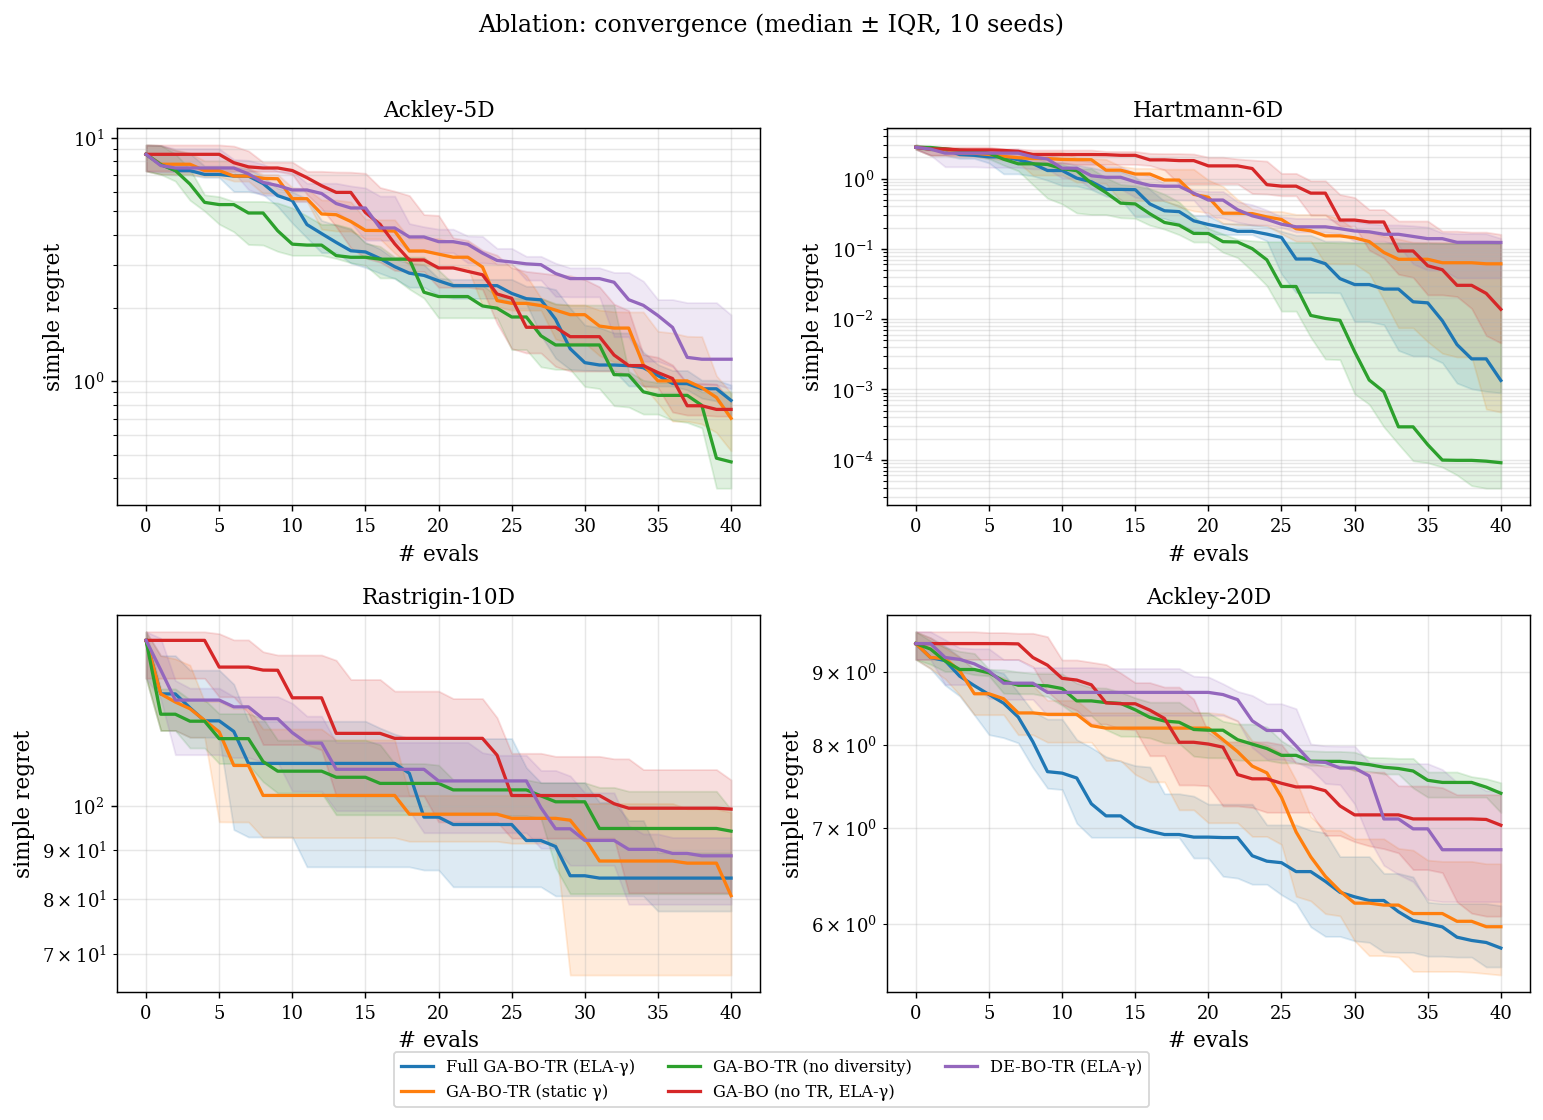

Saved figures_gabotr/ablation_convergence.pdf


In [22]:
# Ablation convergence plot — median ± IQR.
def plot_convergence(results, functions, title: str, filename: str,
                     n_cols: int = 2, palette: Optional[dict] = None,
                     logy: bool = True, figsize=(6, 4)):
    fn_names = list(functions.keys())
    n = len(fn_names); n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0]*n_cols, figsize[1]*n_rows),
                             squeeze=False)
    axes = axes.flatten()
    colors = palette or {}
    for i, fname in enumerate(fn_names):
        ax = axes[i]; f_opt = functions[fname].global_optimum
        for j, (m, fd) in enumerate(results.items()):
            runs = fd.get(fname, [])
            if not runs: continue
            L = min(len(r.best_values) for r in runs)
            curves = np.array([np.asarray(r.best_values[:L]) - f_opt for r in runs])
            med = np.median(curves, axis=0)
            q25 = np.percentile(curves, 25, axis=0)
            q75 = np.percentile(curves, 75, axis=0)
            xs = np.arange(L)
            c = colors.get(m, None)
            line, = ax.plot(xs, np.maximum(med, 1e-10), label=m, color=c, lw=1.8)
            ax.fill_between(xs, np.maximum(q25, 1e-10), np.maximum(q75, 1e-10),
                            color=line.get_color(), alpha=0.15)
        if logy:
            ax.set_yscale("log")
        ax.set_title(fname); ax.set_xlabel("# evals"); ax.set_ylabel("simple regret")
        ax.grid(True, which="both", alpha=0.3)
    for k in range(n, len(axes)): axes[k].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
               ncol=min(len(labels), 3), bbox_to_anchor=(0.5, -0.04), fontsize=9)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")


plot_convergence(ABL_RESULTS, ABL_FUNCTIONS,
                 title="Ablation: convergence (median ± IQR, 10 seeds)",
                 filename="ablation_convergence.pdf", n_cols=2)


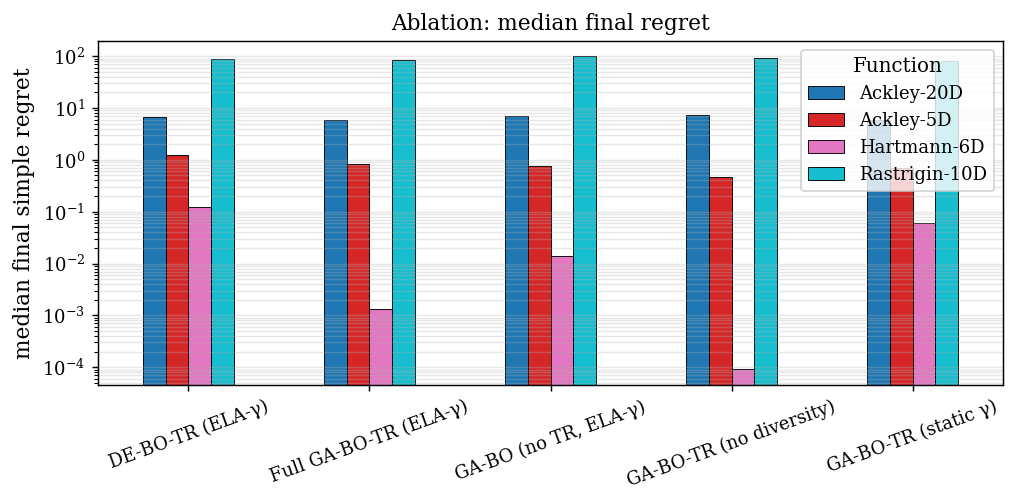

In [23]:
# Ablation bar chart — mean final regret per variant (with 95% bootstrap CI).
def bar_final_regret(results, functions, title: str, filename: str):
    rows = []
    for m, fd in results.items():
        for fname, runs in fd.items():
            f_opt = functions[fname].global_optimum
            finals = np.array([r.best_values[-1] - f_opt for r in runs])
            rows.append({"Method": m, "Function": fname,
                         "Median": float(np.median(finals)),
                         "Q25": float(np.percentile(finals, 25)),
                         "Q75": float(np.percentile(finals, 75))})
    df = pd.DataFrame(rows)

    # pivot for plotting: rows = method, cols = function
    pv = df.pivot(index="Method", columns="Function", values="Median")
    fig, ax = plt.subplots(figsize=(8, 4))
    pv.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.5, colormap="tab10")
    ax.set_ylabel("median final simple regret"); ax.set_xlabel("")
    ax.set_title(title); ax.set_yscale("log")
    ax.grid(axis="y", which="both", alpha=0.3); ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight"); plt.show()
    return df


ABL_DF = bar_final_regret(ABL_RESULTS, ABL_FUNCTIONS,
                          title="Ablation: median final regret",
                          filename="ablation_bar.pdf")


## 7. γ trajectory visualisation

Because the ELA-γ controller re-selects the policy every 5 iterations,
the γ(t) trajectory directly shows how the algorithm reads the landscape
as the archive grows.  Unimodal problems should settle into the `greedy`
or `low` policy after the first re-selection; multimodal problems like
Rastrigin should oscillate among `high` / `power`.


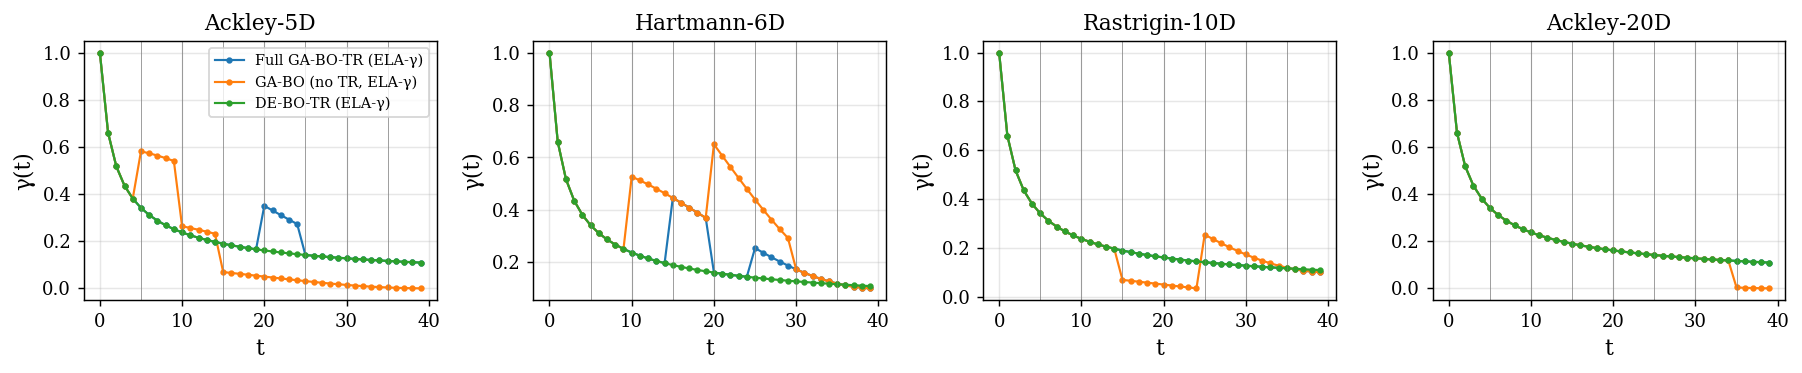

In [24]:
def plot_gamma_trajectories(results, functions, filename: str):
    """Overlay γ(t) for the ELA-γ method on each function (first seed)."""
    fn_names = list(functions.keys())
    fig, axes = plt.subplots(1, len(fn_names), figsize=(3.5*len(fn_names), 3.0),
                             squeeze=False)
    axes = axes.flatten()
    for i, fname in enumerate(fn_names):
        ax = axes[i]
        for mname, fd in results.items():
            if "ELA-γ" not in mname: continue
            runs = fd.get(fname, [])
            if not runs: continue
            r = runs[0]
            if not r.gamma_hist: continue
            t = np.arange(len(r.gamma_hist))
            ax.plot(t, r.gamma_hist, "-o", markersize=2.5, lw=1.2,
                    label=mname)
            # Mark policy transitions (rule vs classifier)
            for j, (tt, pol) in enumerate(zip(t, r.policy_hist)):
                if j % 5 == 0 and j > 0:
                    ax.axvline(tt, color="gray", lw=0.4, alpha=0.5)
        ax.set_title(fname); ax.set_xlabel("t"); ax.set_ylabel("γ(t)")
        ax.grid(alpha=0.3)
        if i == 0: ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight"); plt.show()


plot_gamma_trajectories(ABL_RESULTS, ABL_FUNCTIONS, "gamma_trajectories.pdf")


## 8. γ sensitivity (static schedules)

A sanity-check grid over (γ_init, γ_final) with the cosine schedule and
no ELA controller.  This shows that a single static γ is sub-optimal
across problems (the heatmap has distinct minima per function), which
justifies the ELA controller.


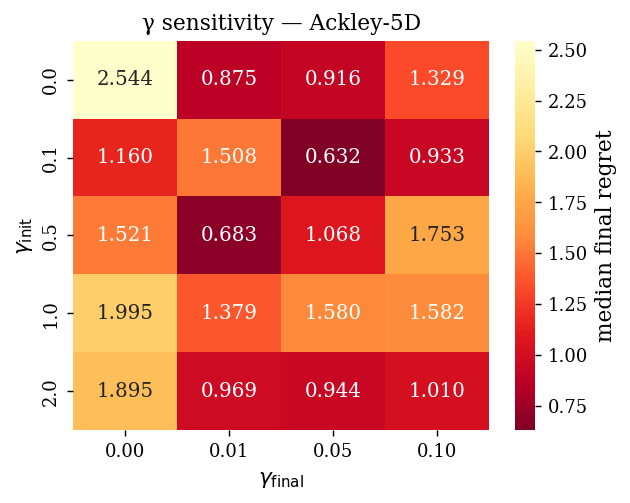

In [25]:
def gamma_sensitivity(tf: TestFunction,
                      gamma_inits  = (0.0, 0.1, 0.5, 1.0, 2.0),
                      gamma_finals = (0.0, 0.01, 0.05, 0.10),
                      n_seeds: int = 5, n_init: int = 5, n_iter: int = 30):
    H = np.zeros((len(gamma_inits), len(gamma_finals)))
    for i, gi in enumerate(gamma_inits):
        for j, gf in enumerate(gamma_finals):
            regrets = []
            for s in range(n_seeds):
                if tf.problem_class == "bbob": reset_bbob(tf)
                algo = GA_BO_TR(
                    bounds=tf.bounds, n_init=n_init, n_iter=n_iter,
                    acq_type="da_ei", optimizer_type="ga",
                    gamma_controller=None,
                    gamma_init=gi, gamma_final=gf, gamma_decay="cosine",
                    use_trust_region=True,
                    ga_pop_init=40, ga_generations=15, mc_samples=128,
                    seed=s,
                )
                r = algo.run(tf, func_name=tf.name)
                regrets.append(r.best_values[-1] - tf.global_optimum)
            H[i, j] = float(np.median(regrets))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(H, annot=True, fmt=".3f",
                xticklabels=[f"{g:.2f}" for g in gamma_finals],
                yticklabels=[f"{g:.1f}" for g in gamma_inits],
                cmap="YlOrRd_r", ax=ax,
                cbar_kws={"label": "median final regret"})
    ax.set_xlabel(r"$\gamma_{\mathrm{final}}$")
    ax.set_ylabel(r"$\gamma_{\mathrm{init}}$")
    ax.set_title(f"γ sensitivity — {tf.name}")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/gamma_sensitivity_{tf.name}.pdf", bbox_inches="tight")
    plt.show()
    return H


_H = gamma_sensitivity(BENCHMARK_FUNCTIONS["Ackley-5D"], n_seeds=5)



---

**Part 2 complete.**  The proposed method `GA_BO_TR`, the ELA-γ controller, theory figure, ablation study and γ sensitivity are now defined.  Part 3 runs the full BBOB-24 benchmark, the strong baselines (HEBO, TuRBO-1, CMA-ES, Optuna-TPE), engineering design problems, statistical tests (Friedman + Nemenyi) and the critical-difference diagram.
